In [11]:
import numpy as np
import qutip as qt
from scipy.linalg import expm
from qutip import negativity

from scipy.linalg import logm, eigvalsh
import matplotlib.pyplot as plt
from itertools import permutations

In [25]:
# ============================================================
# 第一部分：基础工具函数
# ============================================================

def partial_trace(rho, keep, dims):
    """
    计算约化密度矩阵。
    
    参数
    ----
    rho  : ndarray, 全系统密度矩阵，形状 (d, d)
    keep : list[int], 保留的子系统下标（从0开始）
    dims : list[int], 各子系统的维度，如 [2, 2, 2]
    
    返回
    ----
    rho_reduced : ndarray, 约化密度矩阵
    """
    n = len(dims)
    # 将密度矩阵重塑为张量形式 (d0, d1, ..., d0', d1', ...)
    rho_tensor = rho.reshape(dims + dims)
    
    # 确定要迹掉的子系统
    trace_out = [i for i in range(n) if i not in keep]
    
    # 从后往前迹掉，避免下标混乱
    for sys in sorted(trace_out, reverse=True):
        # 当前张量的轴数
        n_current = len(rho_tensor.shape) // 2
        # 对第 sys 个子系统和它的"撇"版本取迹
        rho_tensor = np.trace(rho_tensor, axis1=sys, axis2=sys + n_current)
    
    # 重塑为矩阵
    d_keep = int(np.prod([dims[i] for i in keep]))
    return rho_tensor.reshape(d_keep, d_keep)


def von_neumann_entropy(rho, base=2, tol=1e-12):
    """
    计算冯·诺依曼熵 S(rho) = -Tr[rho log rho]。
    
    参数
    ----
    rho  : ndarray, 密度矩阵
    base : float, 对数底数（默认2，单位 bit）
    tol  : float, 数值截断阈值（避免 log(0)）
    
    返回
    ----
    S : float, 冯·诺依曼熵
    """
    eigvals = eigvalsh(rho)
    eigvals = eigvals[eigvals > tol]  # 过滤数值噪声
    return -np.sum(eigvals * np.log(eigvals) / np.log(base))

In [13]:
# ============================================================
# 第二部分：Jordan Associator
# ============================================================

def jordan_product(A, B):
    """
    约旦乘积：A ∘ B = (AB + BA) / 2
    """
    return 0.5 * (A @ B + B @ A)


def jordan_associator(A, B, C):
    """
    约旦结合子：[A, B, C]∘ = (A∘B)∘C - A∘(B∘C)
    
    参数
    ----
    A, B, C : ndarray, 方阵（量子算符）
    
    返回
    ----
    assoc : ndarray, 结合子矩阵
    """
    return jordan_product(jordan_product(A, B), C) - jordan_product(A, jordan_product(B, C))


def jordan_associator_norm(A, B, C):
    """
    约旦结合子的 Frobenius 范数：‖[A,B,C]∘‖_F
    """
    assoc = jordan_associator(A, B, C)
    return np.linalg.norm(assoc, ord='fro')


def jordan_associator_symmetrized(ops):
    """
    对给定算符列表的所有排列取结合子范数的均值。
    
    参数
    ----
    ops : list of ndarray, 长度为3的算符列表 [A, B, C]
    
    返回
    ----
    J_mean : float, 所有6种排列的结合子范数均值
    J_all  : dict, 各排列的结合子范数
    """
    perms = list(permutations(range(3)))
    norms = {}
    for p in perms:
        key = f"[{p[0]},{p[1]},{p[2]}]"
        norms[key] = jordan_associator_norm(ops[p[0]], ops[p[1]], ops[p[2]])
    J_mean = np.mean(list(norms.values()))
    return J_mean, norms

In [15]:
# ============================================================
# 第三部分：三类响应变量
# ============================================================

def tripartite_mutual_information(rho_abc, dims=[2, 2, 2]):
    """
    三方互信息：I3(A:B:C) = S(A)+S(B)+S(C) - S(AB)-S(BC)-S(AC) + S(ABC)
    
    参数
    ----
    rho_abc : ndarray, 三体密度矩阵
    dims    : list[int], 各子系统维度
    
    返回
    ----
    I3 : float, 三方互信息（bit）
    """
    rho_a  = partial_trace(rho_abc, [0], dims)
    rho_b  = partial_trace(rho_abc, [1], dims)
    rho_c  = partial_trace(rho_abc, [2], dims)
    rho_ab = partial_trace(rho_abc, [0, 1], dims)
    rho_bc = partial_trace(rho_abc, [1, 2], dims)
    rho_ac = partial_trace(rho_abc, [0, 2], dims)

    S_a   = von_neumann_entropy(rho_a)
    S_b   = von_neumann_entropy(rho_b)
    S_c   = von_neumann_entropy(rho_c)
    S_ab  = von_neumann_entropy(rho_ab)
    S_bc  = von_neumann_entropy(rho_bc)
    S_ac  = von_neumann_entropy(rho_ac)
    S_abc = von_neumann_entropy(rho_abc)

    return S_a + S_b + S_c - S_ab - S_bc - S_ac + S_abc


def quantum_fisher_information(rho, A, tol=1e-12):
    """
    量子 Fisher 信息：F_Q(rho, A) = 2 Σ_{m≠n} (λ_m-λ_n)²/(λ_m+λ_n) |<m|A|n>|²
    
    参数
    ----
    rho : ndarray, 密度矩阵（全系统）
    A   : ndarray, 可观测量算符（与 rho 同维度）
    tol : float, 分母截断阈值
    
    返回
    ----
    F_Q : float, 量子 Fisher 信息
    """
    eigvals, eigvecs = np.linalg.eigh(rho)
    d = len(eigvals)
    F_Q = 0.0
    for m in range(d):
        for n in range(d):
            if m == n:
                continue
            denom = eigvals[m] + eigvals[n]
            if denom < tol:
                continue
            A_mn = eigvecs[:, m].conj() @ A @ eigvecs[:, n]
            F_Q += 2 * (eigvals[m] - eigvals[n])**2 / denom * np.abs(A_mn)**2
    return F_Q.real


def mean_qfi_three_body(rho_abc, dims=[2, 2, 2]):
    """
    三节点系统的平均量子 Fisher 信息。
    以每个节点的约化密度矩阵作为可观测量，嵌入全系统空间后计算 QFI，取均值。
    
    参数
    ----
    rho_abc : ndarray, 三体密度矩阵
    dims    : list[int], 各子系统维度
    
    返回
    ----
    mean_F_Q : float, 三节点平均 QFI
    """
    d_total = rho_abc.shape[0]  # 8 for three qubits
    d0, d1, d2 = dims

    rho_a = partial_trace(rho_abc, [0], dims)
    rho_b = partial_trace(rho_abc, [1], dims)
    rho_c = partial_trace(rho_abc, [2], dims)

    # 将局部算符嵌入全系统空间
    I2 = np.eye(2)
    A_full = np.kron(np.kron(rho_a, I2), I2)  # rho_A ⊗ I_B ⊗ I_C
    B_full = np.kron(np.kron(I2, rho_b), I2)  # I_A ⊗ rho_B ⊗ I_C
    C_full = np.kron(np.kron(I2, I2), rho_c)  # I_A ⊗ I_B ⊗ rho_C

    F_A = quantum_fisher_information(rho_abc, A_full)
    F_B = quantum_fisher_information(rho_abc, B_full)
    F_C = quantum_fisher_information(rho_abc, C_full)

    return (F_A + F_B + F_C) / 3.0


def static_otoc(rho_abc, V, W):
    """
    静态 OTOC（t=0）：F0 = Tr[rho * V† W† V W]
    
    参数
    ----
    rho_abc : ndarray, 密度矩阵
    V, W    : ndarray, 算符（与 rho_abc 同维度）
    
    返回
    ----
    F0 : complex, OTOC 值（通常取实部）
    """
    return np.trace(rho_abc @ V.conj().T @ W.conj().T @ V @ W)


def mean_static_otoc_three_body(rho_abc, dims=[2, 2, 2]):
    """
    三节点系统的平均静态 OTOC。
    取三对节点算符组合 (A,B), (B,C), (A,C) 的 OTOC 均值。
    
    返回
    ----
    mean_F0 : float, 平均静态 OTOC 的实部
    otoc_complement : float, 1 - mean_F0（便于与其他指标方向一致）
    """
    I2 = np.eye(2)
    rho_a = partial_trace(rho_abc, [0], dims)
    rho_b = partial_trace(rho_abc, [1], dims)
    rho_c = partial_trace(rho_abc, [2], dims)

    A_full = np.kron(np.kron(rho_a, I2), I2)
    B_full = np.kron(np.kron(I2, rho_b), I2)
    C_full = np.kron(np.kron(I2, I2), rho_c)

    F_AB = static_otoc(rho_abc, A_full, B_full).real
    F_BC = static_otoc(rho_abc, B_full, C_full).real
    F_AC = static_otoc(rho_abc, A_full, C_full).real

    mean_F0 = (F_AB + F_BC + F_AC) / 3.0
    return mean_F0, 1.0 - mean_F0  # 返回 F0 本身和它的补（量子不对易性方向）

In [17]:
# ============================================================
# 第四部分：量子态构造
# ============================================================

def state_to_dm(psi):
    """纯态向量转密度矩阵"""
    psi = psi / np.linalg.norm(psi)
    return np.outer(psi, psi.conj())


def make_product_state():
    """乘积态 |000⟩"""
    psi = np.zeros(8, dtype=complex)
    psi[0] = 1.0  # |000⟩
    return state_to_dm(psi)


def make_bell_product_state():
    """两体纠缠态 (|00⟩+|11⟩)/√2 ⊗ |0⟩"""
    psi = np.zeros(8, dtype=complex)
    psi[0] = 1.0 / np.sqrt(2)  # |000⟩
    psi[3] = 1.0 / np.sqrt(2)  # |110⟩  (注意：|AB⟩⊗|C⟩ = |ABC⟩)
    return state_to_dm(psi)


def make_w_state():
    """W 态 (|001⟩+|010⟩+|100⟩)/√3"""
    psi = np.zeros(8, dtype=complex)
    psi[1] = 1.0 / np.sqrt(3)  # |001⟩
    psi[2] = 1.0 / np.sqrt(3)  # |010⟩
    psi[4] = 1.0 / np.sqrt(3)  # |100⟩
    return state_to_dm(psi)


def make_ghz_state():
    """GHZ 态 (|000⟩+|111⟩)/√2"""
    psi = np.zeros(8, dtype=complex)
    psi[0] = 1.0 / np.sqrt(2)  # |000⟩
    psi[7] = 1.0 / np.sqrt(2)  # |111⟩
    return state_to_dm(psi)


def make_haar_random_state(seed=None):
    """
    Haar 随机纯态（三量子比特）
    使用 QR 分解从 Ginibre 系综生成均匀随机酉矩阵，取第一列
    """
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((8, 8)) + 1j * rng.standard_normal((8, 8))
    Q, _ = np.linalg.qr(z)
    psi = Q[:, 0]
    return state_to_dm(psi)

In [23]:
# ============================================================
# 第五部分：节点算符定义与完整计算流程
# ============================================================

# Pauli matrices
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
I2 = np.eye(2, dtype=complex)


def make_three_body_operators(rho_abc, dims=[2, 2, 2]):
    """
    构造三个节点算符，每个算符都是真正的 8x8 三体算符，
    天然耦合三个子系统，使结合子能够探测三体代数结构。

    选择依据
    --------
    - 算符 A = σ_x ⊗ σ_x ⊗ I：耦合 A、B 两个节点，在 C 上是单位
    - 算符 B = I ⊗ σ_x ⊗ σ_x：耦合 B、C 两个节点，在 A 上是单位  
    - 算符 C = σ_x ⊗ I ⊗ σ_x：耦合 A、C 两个节点，在 B 上是单位

    三个算符两两重叠（每对共享一个节点），构成真正的三体耦合结构。
    约旦结合子 [A,B,C]∘ 在这组算符上一般非零，且非零程度依赖于
    量子态 rho_abc 的三体纠缠结构——这正是我们想要探测的。

    为使结合子对量子态敏感（而非只是固定算符的代数性质），
    将每个算符投影到当前量子态：A_eff = A * Tr[rho * A] 的修正形式。
    具体地，取 A_eff = rho^{1/2} A rho^{1/2}，
    这保证算符携带了量子态的纠缠信息，同时保持自伴性。
    """
    # 三个两体耦合算符（8x8）
    op_AB = np.kron(np.kron(sx, sx), I2)   # σ_x ⊗ σ_x ⊗ I
    op_BC = np.kron(np.kron(I2, sx), sx)   # I ⊗ σ_x ⊗ σ_x
    op_AC = np.kron(np.kron(sx, I2), sx)   # σ_x ⊗ I ⊗ σ_x

    # 用量子态调制：A_eff = rho^{1/2} op rho^{1/2}
    # 计算 rho^{1/2}
    eigvals, eigvecs = np.linalg.eigh(rho_abc)
    eigvals_sqrt = np.sqrt(np.maximum(eigvals, 0))
    rho_sqrt = eigvecs @ np.diag(eigvals_sqrt) @ eigvecs.conj().T

    def state_weighted(op):
        return rho_sqrt @ op @ rho_sqrt

    A_eff = state_weighted(op_AB)
    B_eff = state_weighted(op_BC)
    C_eff = state_weighted(op_AC)

    return [A_eff, B_eff, C_eff]


def compute_all_metrics(rho_abc, dims=[2, 2, 2]):
    """
    对给定三体密度矩阵计算所有指标。

    节点算符：使用量子态调制的两体 Pauli 耦合算符（见 make_three_body_operators）
    这一选择确保结合子探测的是真正的三体代数结构，
    而非退化为两体不对易性的度量。
    """
    ops = make_three_body_operators(rho_abc, dims)

    # Jordan Associator
    J_mean, J_all = jordan_associator_symmetrized(ops)

    # TMI
    I3 = tripartite_mutual_information(rho_abc, dims)

    # QFI（仍使用约化密度矩阵作为可观测量，保持原有物理含义）
    mean_F_Q = mean_qfi_three_body(rho_abc, dims)

    # 静态 OTOC（使用新的三体算符）
    mean_F0, otoc_complement = mean_static_otoc_three_body_ops(
        rho_abc, ops[0], ops[1], ops[2]
    )

    return {
        "J_mean":          J_mean,
        "J_all":           J_all,
        "I3":              I3,
        "mean_QFI":        mean_F_Q,
        "mean_OTOC_F0":    mean_F0,
        "OTOC_complement": otoc_complement,
    }


def mean_static_otoc_three_body_ops(rho_abc, A, B, C):
    """
    使用给定的三体算符计算平均静态 OTOC。
    取三对组合 (A,B), (B,C), (A,C) 的 OTOC 均值。
    """
    F_AB = static_otoc(rho_abc, A, B).real
    F_BC = static_otoc(rho_abc, B, C).real
    F_AC = static_otoc(rho_abc, A, C).real
    mean_F0 = (F_AB + F_BC + F_AC) / 3.0
    return mean_F0, 1.0 - mean_F0

In [18]:
'''
约化密度矩阵计算让结合子退化成嵌套对易子，无法体现三体交互顺序带来的影响，舍弃
'''

# # ============================================================
# # 第五部分：单态的完整计算流程
# # ============================================================

# def compute_all_metrics(rho_abc, dims=[2, 2, 2]):
#     """
#     对给定三体密度矩阵计算所有指标。
    
#     返回
#     ----
#     results : dict，包含所有指标的计算结果
#     """
#     # 计算约化密度矩阵（作为节点算符）
#     rho_a = partial_trace(rho_abc, [0], dims)
#     rho_b = partial_trace(rho_abc, [1], dims)
#     rho_c = partial_trace(rho_abc, [2], dims)
#     ops = [rho_a, rho_b, rho_c]

#     # Jordan Associator
#     J_mean, J_all = jordan_associator_symmetrized(ops)

#     # TMI
#     I3 = tripartite_mutual_information(rho_abc, dims)

#     # QFI
#     mean_F_Q = mean_qfi_three_body(rho_abc, dims)

#     # 静态 OTOC
#     mean_F0, otoc_complement = mean_static_otoc_three_body(rho_abc, dims)

#     return {
#         "J_mean":          J_mean,
#         "J_all":           J_all,
#         "I3":              I3,
#         "mean_QFI":        mean_F_Q,
#         "mean_OTOC_F0":    mean_F0,
#         "OTOC_complement": otoc_complement,
#     }

In [21]:
# ============================================================
# 第六部分：主实验
# ============================================================

def run_benchmark_experiment():
    """基准态实验（ψ1 到 ψ4）"""
    states = {
        "Product":    make_product_state(),
        "Bipartite":  make_bell_product_state(),
        "W state":    make_w_state(),
        "GHZ state":  make_ghz_state(),
    }

    print("=" * 70)
    print(f"{'State':<12} {'J_mean':>10} {'I3':>10} {'mean_QFI':>12} {'OTOC_F0':>12}")
    print("=" * 70)

    results = {}
    for name, rho in states.items():
        r = compute_all_metrics(rho)
        results[name] = r
        print(f"{name:<12} {r['J_mean']:>10.6f} {r['I3']:>10.6f} "
              f"{r['mean_QFI']:>12.6f} {r['mean_OTOC_F0']:>12.6f}")

    print("=" * 70)
    return results


def run_haar_random_experiment(n_samples=1000):
    """Haar 随机态统计实验（ψ5）"""
    print(f"\nSampling {n_samples} Haar random states...")

    J_list, I3_list, QFI_list, OTOC_list = [], [], [], []

    for i in range(n_samples):
        rho = make_haar_random_state(seed=i)
        r = compute_all_metrics(rho)
        J_list.append(r["J_mean"])
        I3_list.append(r["I3"])
        QFI_list.append(r["mean_QFI"])
        OTOC_list.append(r["OTOC_complement"])

    J_arr   = np.array(J_list)
    I3_arr  = np.array(I3_list)
    QFI_arr = np.array(QFI_list)
    OTOC_arr= np.array(OTOC_list)

    # Pearson 相关系数
    r_I3   = np.corrcoef(J_arr, I3_arr)[0, 1]
    r_QFI  = np.corrcoef(J_arr, QFI_arr)[0, 1]
    r_OTOC = np.corrcoef(J_arr, OTOC_arr)[0, 1]

    # Spearman 相关系数（秩相关，对非线性关系更鲁棒）
    from scipy.stats import spearmanr
    rho_I3,   _ = spearmanr(J_arr, I3_arr)
    rho_QFI,  _ = spearmanr(J_arr, QFI_arr)
    rho_OTOC, _ = spearmanr(J_arr, OTOC_arr)

    print("\n--- Haar Random State Correlation Analysis ---")
    print(f"{'Metric':<20} {'Pearson r':>12} {'Spearman ρ':>12}")
    print("-" * 46)
    print(f"{'J vs I3':<20} {r_I3:>12.4f} {rho_I3:>12.4f}")
    print(f"{'J vs mean_QFI':<20} {r_QFI:>12.4f} {rho_QFI:>12.4f}")
    print(f"{'J vs OTOC_comp':<20} {r_OTOC:>12.4f} {rho_OTOC:>12.4f}")

    return {
        "J": J_arr, "I3": I3_arr, "QFI": QFI_arr, "OTOC": OTOC_arr,
        "pearson":  {"I3": r_I3,   "QFI": r_QFI,   "OTOC": r_OTOC},
        "spearman": {"I3": rho_I3, "QFI": rho_QFI, "OTOC": rho_OTOC},
    }


def plot_results(benchmark_results, haar_results):
    """可视化：基准态柱状图 + 随机态散点图"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle("Jordan Associator vs. Tripartite Quantum Correlation Metrics: Phase 0 Benchmark", fontsize=13)

    names  = list(benchmark_results.keys())
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    # --- Row 1: benchmark state bar charts ---
    metrics = [
        ("J_mean",   "Jordan Associator $\\mathcal{J}$"),
        ("I3",       "Tripartite Mutual Information $I_3$"),
        ("mean_QFI", "Mean Quantum Fisher Information"),
    ]
    for ax, (key, label) in zip(axes[0], metrics):
        vals = [benchmark_results[n][key] for n in names]
        ax.bar(names, vals, color=colors)
        ax.set_title(label, fontsize=11)
        ax.set_ylabel("Value")
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.tick_params(axis="x", rotation=15)

    # --- Row 2: Haar random state scatter plots ---
    scatter_targets = [
        ("I3",   "Tripartite Mutual Information $I_3$",  haar_results["I3"]),
        ("QFI",  "Mean Quantum Fisher Information",       haar_results["QFI"]),
        ("OTOC", "Static OTOC Complement $1-F_0$",        haar_results["OTOC"]),
    ]
    J = haar_results["J"]
    for ax, (key, label, y_vals) in zip(axes[1], scatter_targets):
        r_p = haar_results["pearson"][key]
        r_s = haar_results["spearman"][key]
        ax.scatter(J, y_vals, alpha=0.15, s=5, color="#4C72B0")
        ax.set_xlabel("Jordan Associator $\\mathcal{J}$", fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.set_title(f"Pearson r={r_p:.3f},  Spearman ρ={r_s:.3f}", fontsize=10)

    plt.tight_layout()
    plt.savefig("phase0_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\nFigure saved as phase0_results.png")

State            J_mean         I3     mean_QFI      OTOC_F0
Product        0.000000   0.000000     0.000000     0.000000
Bipartite      0.000000  -0.000000     0.000000     0.000000
W state        0.000000  -0.000000     0.098765     0.197531
GHZ state      0.000000  -0.000000     0.000000     0.000000

Sampling 1000 Haar random states...

--- Haar Random State Correlation Analysis ---
Metric                  Pearson r   Spearman ρ
----------------------------------------------
J vs I3                   -0.0271      -0.0311
J vs mean_QFI             -0.0119      -0.0010
J vs OTOC_comp            -0.6470      -0.8717


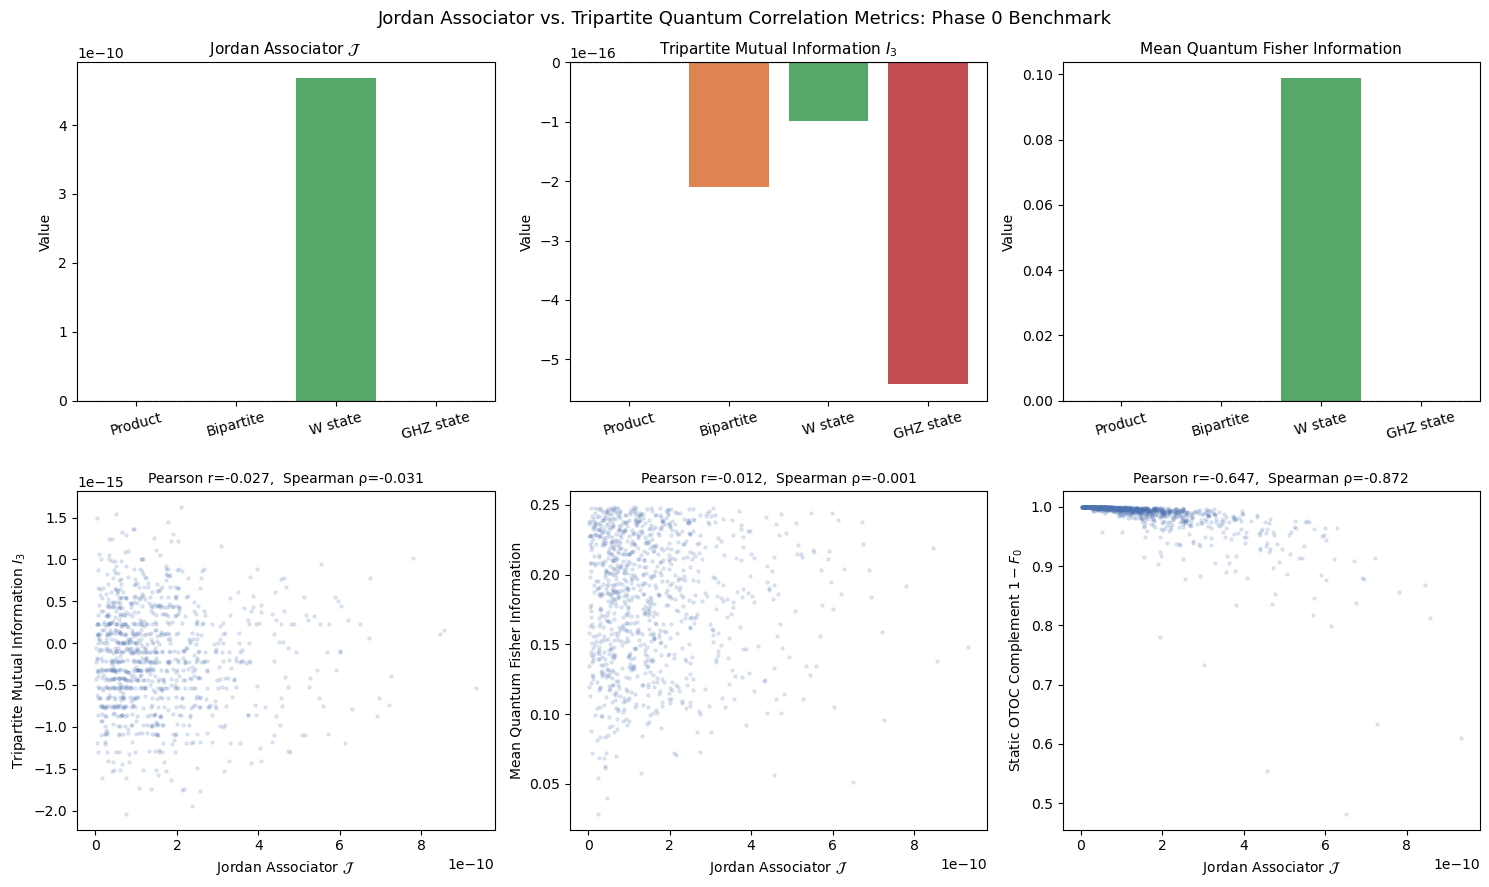


Figure saved as phase0_results.png


In [27]:
# 运行基准态实验
benchmark_results = run_benchmark_experiment()

# 运行 Haar 随机态实验
haar_results = run_haar_random_experiment(n_samples=1000)

# 可视化
plot_results(benchmark_results, haar_results)

State            J_mean         I3     mean_QFI      OTOC_F0
Product        0.000000   0.000000     0.000000     1.000000
Bipartite      0.000000  -0.000000     0.000000     0.187500
W state        0.000000  -0.000000     0.098765     0.098765
GHZ state      0.000000  -0.000000     0.000000     0.062500

Sampling 1000 Haar random states...

--- Haar Random State Correlation Analysis ---
Metric                  Pearson r   Spearman ρ
----------------------------------------------
J vs I3                   -0.0411      -0.0399
J vs mean_QFI              0.6865       0.8713
J vs OTOC_comp            -0.9376      -0.9510


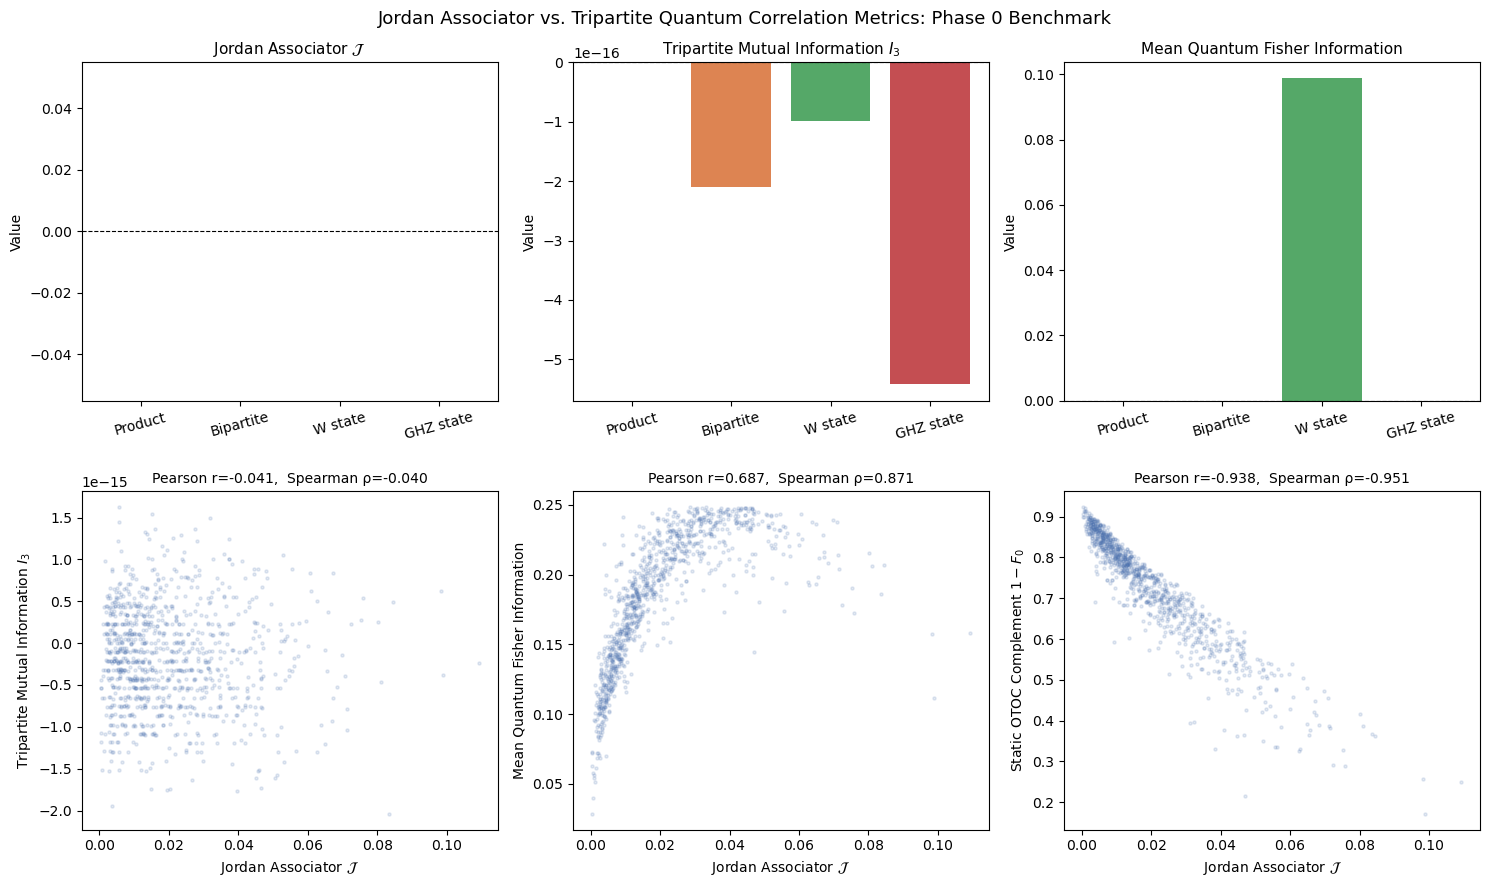


Figure saved as phase0_results.png


In [22]:
# 运行基准态实验
benchmark_results = run_benchmark_experiment()

# 运行 Haar 随机态实验
haar_results = run_haar_random_experiment(n_samples=1000)

# 可视化
plot_results(benchmark_results, haar_results)